<a href="https://colab.research.google.com/github/Chanbomey/Chanbomey/blob/main/Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using Machine Learning: A Comparative Study of Decision Tree, K-Nearest Neighber (KNN), Multi-Layer Perceptron (MLP), and Random Forest Predictive Models



**BUSINESS UNDERSTANDING**
<br>
Customer churn refers to the loss of customers when they discontinue their service with a company. It is an important business metric because acquiring new customers is typically more expensive than retaining existing ones. High churn rates may indicate serious issues such as poor service quality, high pricing, or strong competition, which can reduce revenue and profitability. Predicting churn helps companies identify customers who are likely to cancel their service with the business and implement strategies to improve retention.
<br>
<br>
Compared to industries such as banking or healthcare, customer churn in the telecommunications industry is particularly common and costly. This is largely due to high competition, low switching barriers, and comparable pricing and service plans among providers, making it easier for customers to change companies.
<br>
<br>
Therefore, from a business perspective, customer churn problem can be defined as the task of identifying customers who are at risk of leaving the telecom provider, understanding the reasons behind their potential departure, implementing proactive measures to retain them, and improve long-term profitability.
<br>
<br>
In this project, The customer churn problem can be framed as a binary classification task by defining churn as the target variable with two possible outcomes: 1 or 'Y' (customer churned) and 0 or 'N' (customer retained). The dataset includes historical customer information such as demographic characteristics, service usage data, subscription details, customer category, and tenure. These variables act as predictors, while the churn variable serves as the labeled outcome that the model aims to predict. By leveraging historical customer data, the model aims to support data-driven decision-making and improve customer retention strategies.
<br>
<br>

**DATA UNDERSTANDING**
<br>
VARIABLE DESCRIPTIONS:<br>
cust_id: Customer ID<br>
region: Geographical region of the customer<br>
tenure: Number of months the customer has stayed with the company<br>
age: Customer's age <br>
marital: Customer's marital status<br>
address: Number of years at current address<br>
income: Customer's income<br>
ed: Education level<br>
employ: Years with current employer<br>
retire: Whether the customer is retired<br>
gender: Customer's gender<br>
reside: Number of people residing in the household<br>
tollfree: Whether the customer subscribes to toll-free service<br>
equip: Whether the customer has equipment rental<br>
callcard: Whether the customer uses a calling card<br>
wireless: Whether the customer has wireless service<br>
longmon: Monthly charge for long-distance calls<br>
tollmon: Monthly charge for toll-free service<br>
equipmon: Monthly charge for equipment rental<br>
cardmon: Monthly charge for calling card service<br>
wiremon: Monthly charge for wireless service<br>
longten: Total charge for long-distance calls over entire tenure<br>
tollten: Total charge for toll-free service over entire tenure<br>
equipten: Total charge for equipment rental over entire tenure<br>
cardten: Total charge for calling card service over entire tenure<br>
wireten: Total charge for wireless service over entire tenure<br>
multline: Whether the customer has multiple lines<br>
voice: Whether the customer has voice mail<br>
pager: Whether the customer has a pager<br>
internet: Whether the customer has internet service<br>
callid: Whether the customer has caller ID service<br>
callwait: Whether the customer has call waiting service<br>
forward: Whether the customer has call forwarding service<br>
confer: Whether the customer has conference calling service<br>
ebill: Whether the customer receives electronic billing<br>
loglong: Logarithm of long-distance call charges<br>
lninc: Logarithm of income<br>
custcat: Customer category<br>
churn: Whether the customer churned<br>
<br>
Key variables can be grouped into several categories:

- Demographic and financial variables (e.g., age, income, education) provide insights into customer characteristics and potential price sensitivity.
- Customer stability variables (e.g., tenure, years at address, employment duration) reflect customer loyalty and likelihood of remaining with the company.
- Service usage variables (e.g., monthly and total charges for services such as wireless, toll-free, and equipment rental) capture customer engagement and perceived value of the service.
- Derived variables (e.g., loglong, lninc) are transformations used to reduce skewness and improve model performance.
- Categorical variables (e.g., region, customer category) help identify customer segments with different behavioral patterns.

The target variable is **churn**, which is a binary categorical variable indicating whether a customer has discontinued service.

Understanding these variables provides a foundation for identifying patterns associated with churn behavior and developing predictive models to classify future customers.

# **1. Upload and clean data**

In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Read data
customer_churn = pd.read_csv("/content/drive/MyDrive/IS470_data/CutomerChurnData.csv")
customer_churn

,cust_id,region,tenure,age,marital,address,income,ed,employ,retire,...,internet,callid,callwait,forward,confer,ebill,loglong,lninc,custcat,churn
0,C00124,R2,13,44,Y,9,64,E4,5,N,...,N,N,N,Y,N,N,1.308,4.159,C1,Y
1,C00125,R3,68,52,Y,24,116,E1,29,N,...,N,Y,Y,N,Y,N,2.899,4.754,C3,N
2,C00126,R2,23,30,Y,9,30,E1,2,N,...,N,Y,N,Y,Y,N,1.841,3.401,C3,N
3,C00127,R3,45,22,Y,2,19,E2,4,N,...,Y,N,Y,N,N,Y,2.389,2.944,C2,Y
4,C00128,R3,45,59,Y,7,166,E4,31,N,...,N,Y,Y,Y,Y,N,2.277,5.112,C3,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C01119,R1,50,43,N,6,27,E3,4,N,...,N,Y,Y,Y,Y,N,2.708,3.296,C3,N
996,C01120,R1,34,52,Y,2,106,E2,19,N,...,Y,Y,N,Y,Y,N,1.599,4.663,C3,N
997,C01121,R1,15,46,Y,17,63,E5,1,N,...,Y,Y,N,Y,Y,Y,1.308,4.143,C4,Y
998,C01122,R1,7,34,N,2,22,E5,5,N,...,N,N,N,N,N,N,1.537,3.091,C1,N


In [4]:
# Show all the heading
customer_churn.keys()

Index(['cust_id', 'region', 'tenure', 'age', 'marital', 'address', 'income',
       'ed', 'employ', 'retire', 'gender', 'reside', 'tollfree', 'equip',
       'callcard', 'wireless', 'longmon', 'tollmon', 'equipmon', 'cardmon',
       'wiremon', 'longten', 'tollten', 'equipten', 'cardten', 'wireten',
       'multline', 'voice', 'pager', 'internet', 'callid', 'callwait',
       'forward', 'confer', 'ebill', 'loglong', 'lninc', 'custcat', 'churn'],
      dtype='object')

In [5]:
# Examine the number of rows and columns
customer_churn.shape

(1000, 39)

In [6]:
# Examine missing value
customer_churn.isnull().sum()

,0
cust_id,0
region,0
tenure,0
age,0
marital,0
address,0
income,0
ed,0
employ,0
retire,0


Missing values were examined using customer_churn.isnull().sum(). The results show that no variables contain missing observations, indicating that the dataset is complete and clean.

In [7]:
# Examine variable type
customer_churn.dtypes

,0
cust_id,object
region,object
tenure,int64
age,int64
marital,object
address,int64
income,int64
ed,object
employ,int64
retire,object


In [8]:
# Display all numeric variables
customer_churn.select_dtypes(include=['number'])

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,equipten,cardten,wireten,loglong,lninc
0,13,44,9,64,5,2,3.70,0.00,0.0,7.50,0.0,37.45,0.00,0.00,110,0.0,1.308,4.159
1,68,52,24,116,29,2,18.15,18.00,0.0,30.25,0.0,1300.60,1247.20,0.00,2150,0.0,2.899,4.754
2,23,30,9,30,2,4,6.30,0.00,0.0,0.00,0.0,157.05,0.00,0.00,0,0.0,1.841,3.401
3,45,22,2,19,4,5,10.90,0.00,0.0,8.75,0.0,504.50,0.00,0.00,415,0.0,2.389,2.944
4,45,59,7,166,31,5,9.75,28.50,0.0,12.00,0.0,449.05,1240.15,0.00,505,0.0,2.277,5.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,43,6,27,4,1,15.00,45.25,0.0,52.75,0.0,817.85,2320.25,0.00,2645,0.0,2.708,3.296
996,34,52,2,106,19,2,4.95,19.00,0.0,13.50,0.0,153.50,649.35,0.00,430,0.0,1.599,4.663
997,15,46,17,63,1,2,3.70,16.50,42.5,0.00,33.1,40.55,207.35,547.95,0,475.3,1.308,4.143
998,7,34,2,22,5,1,4.65,0.00,25.6,0.00,0.0,29.35,0.00,179.10,0,0.0,1.537,3.091


In [9]:
# Display all categorical variables
customer_churn.select_dtypes(include=['category'])

""
0
1
2
3
4
...
995
996
997
998


In [10]:
# Change categorical variables to "category"
customer_churn['cust_id']  = customer_churn['cust_id'].astype('category')
customer_churn['region']   = customer_churn['region'].astype('category')
customer_churn['marital']  = customer_churn['marital'].astype('category')
customer_churn['ed']       = customer_churn['ed'].astype('category')
customer_churn['retire']   = customer_churn['retire'].astype('category')
customer_churn['gender']   = customer_churn['gender'].astype('category')
customer_churn['tollfree'] = customer_churn['tollfree'].astype('category')
customer_churn['equip']    = customer_churn['equip'].astype('category')
customer_churn['callcard'] = customer_churn['callcard'].astype('category')
customer_churn['wireless'] = customer_churn['wireless'].astype('category')
customer_churn['multline'] = customer_churn['multline'].astype('category')
customer_churn['voice']    = customer_churn['voice'].astype('category')
customer_churn['pager']    = customer_churn['pager'].astype('category')
customer_churn['internet'] = customer_churn['internet'].astype('category')
customer_churn['callid']   = customer_churn['callid'].astype('category')
customer_churn['callwait'] = customer_churn['callwait'].astype('category')
customer_churn['forward']  = customer_churn['forward'].astype('category')
customer_churn['confer']   = customer_churn['confer'].astype('category')
customer_churn['ebill']    = customer_churn['ebill'].astype('category')
customer_churn['custcat']  = customer_churn['custcat'].astype('category')
customer_churn['churn']    = customer_churn['churn'].astype('category')

In [11]:
# Examine variable type
customer_churn.dtypes

,0
cust_id,category
region,category
tenure,int64
age,int64
marital,category
address,int64
income,int64
ed,category
employ,int64
retire,category


In [12]:
# Drop cust_id variable
customer_churn = customer_churn.drop('cust_id', axis=1)
display(customer_churn.head())

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,internet,callid,callwait,forward,confer,ebill,loglong,lninc,custcat,churn
0,R2,13,44,Y,9,64,E4,5,N,N,...,N,N,N,Y,N,N,1.308,4.159,C1,Y
1,R3,68,52,Y,24,116,E1,29,N,Y,...,N,Y,Y,N,Y,N,2.899,4.754,C3,N
2,R2,23,30,Y,9,30,E1,2,N,N,...,N,Y,N,Y,Y,N,1.841,3.401,C3,N
3,R3,45,22,Y,2,19,E2,4,N,Y,...,Y,N,Y,N,N,Y,2.389,2.944,C2,Y
4,R3,45,59,Y,7,166,E4,31,N,N,...,N,Y,Y,Y,Y,N,2.277,5.112,C3,N


cust_id represents a unique identifier for each customer and does not contain meaningful behavioral or demographic information. Since it has no predictive value and may introduce noise or overfitting, it was excluded from the modeling process.

# **2. Exploratory Data Analysis**

In [13]:
# Generate the correlation matrix of all numeric variables
customer_churn.select_dtypes(include=['number']).corr()

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,equipten,cardten,wireten,loglong,lninc
tenure,1.000000,0.475715,0.531723,0.260311,0.520837,0.003392,0.707012,0.183964,-0.060533,0.464380,0.122197,0.743025,0.465131,0.305777,0.671865,0.318131,0.834781,0.317191
age,0.475715,1.000000,0.648858,0.375201,0.667698,-0.219699,0.399567,0.108035,-0.087599,0.357184,0.035937,0.423347,0.255622,0.057875,0.429788,0.102269,0.423413,0.408809
address,0.531723,0.648858,1.000000,0.269532,0.473235,-0.174909,0.494289,0.130641,-0.074199,0.343841,0.019519,0.519205,0.298040,0.079887,0.465525,0.110926,0.488836,0.282395
income,0.260311,0.375201,0.269532,1.000000,0.611087,-0.099252,0.216594,0.169940,-0.035326,0.176103,0.098222,0.232504,0.249691,0.012987,0.203118,0.123740,0.225944,0.850498
employ,0.520837,0.667698,0.473235,0.611087,1.000000,-0.104103,0.457547,0.189690,-0.159914,0.344947,0.017875,0.489562,0.342825,-0.001937,0.443235,0.099254,0.456350,0.668575
reside,0.003392,-0.219699,-0.174909,-0.099252,-0.104103,1.000000,-0.008030,0.076684,-0.009835,0.020076,0.048737,-0.011136,0.018758,0.009561,0.005268,0.038325,-0.003076,-0.113496
longmon,0.707012,0.399567,0.494289,0.216594,0.457547,-0.008030,1.000000,0.132686,-0.043699,0.465429,0.070288,0.980346,0.345019,0.202495,0.648830,0.216786,0.871126,0.250000
tollmon,0.183964,0.108035,0.130641,0.169940,0.189690,0.076684,0.132686,1.000000,0.070591,0.336954,0.462594,0.133696,0.801161,0.140615,0.235686,0.448021,0.173010,0.190633
equipmon,-0.060533,-0.087599,-0.074199,-0.035326,-0.159914,-0.009835,-0.043699,0.070591,1.000000,-0.003648,0.534480,-0.043922,0.064685,0.811252,-0.013271,0.425448,-0.061391,0.031592
cardmon,0.464380,0.357184,0.343841,0.176103,0.344947,0.020076,0.465429,0.336954,-0.003648,1.000000,0.267844,0.485595,0.375519,0.164978,0.878379,0.283412,0.453414,0.215430


The correlation matrix of the numerical variables reveals several strong positive relationships and no strong negative relationships. <br>
Extremely high correlations are observed between monthly and total charge variables, such as longmon and longten (0.980), cardmon and cardten (0.878), wiremon and wireten (0.895), and equipmon and equipten (0.811). These strong relationships are expected, as total charges accumulate over time based on monthly usage.

Similarly, strong correlations are observed between original variables and their log-transformed counterparts, including income and lninc (0.850), as well as longmon and loglong (0.871). This confirms that the log variables represent scaled transformations of the original measures.

Other notable relationships include the strong positive correlation between tenure and longten (0.743), indicating that customers with longer tenure naturally accumulate higher total spending. Additionally, age and employ (0.668) show a strong positive relationship, suggesting that older customers tend to have more years of employment. The correlation between employ and income (0.611) further reflects that longer employment duration is associated with higher income levels.

An interesting finding is the strong positive correlation between tenure and longmon (0.707), suggesting that customers who have remained with the company longer also tend to spend more on long-distance services monthly. This relationship may need further visualization to better understand their association and understanding for customer behavior.

Text(0.5, 1.0, 'Countplot of churn in customer_churn data set')

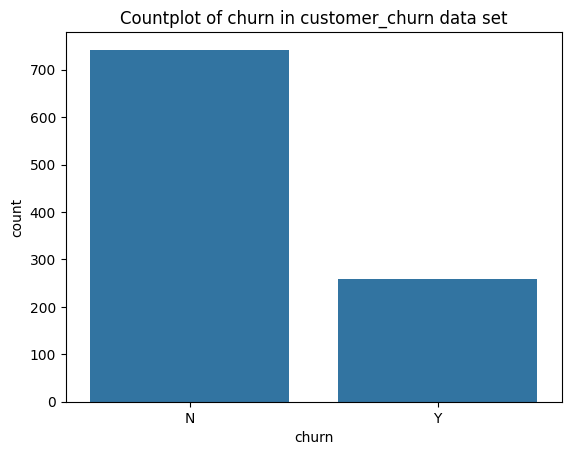

In [14]:
# Countplot a categorical variable: churn
snsplot = sns.countplot(x = 'churn', data = customer_churn)
snsplot.set_title("Countplot of churn in customer_churn data set")

The countplot displays the distribution of the categorical variable churn, showing the number of customers who stayed (N) versus those who churned (Y). The chart indicates that the majority of customers fall into the non-churn category, with substantially more observations than the churn category.

The data is imbalanced, as non-churners significantly outnumber churners. Such class imbalance can bias predictive models toward the majority class, potentially resulting in high overall accuracy but poor performance in correctly identifying churn cases.

(0.0, 100.0)

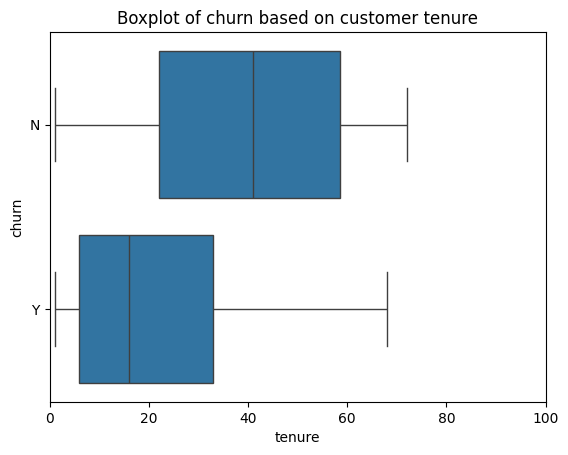

In [15]:
# Examine relationships between numeric and categorical variables: churn by tenure
snsplot = sns.boxplot(x='tenure', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer tenure")
snsplot.set_xlim([0, 100])

The boxplot compares the distribution of customer tenure between customers who churned (Y) and those who did not churn (N).

From the plot, customers who did not churn have a noticeably higher median tenure compared to customers who churned. The interquartile range for non-churners is also shifted toward higher tenure values, indicating that a substantial portion of retained customers have been with the company for a longer period. In contrast, churned customers tend to have lower tenure overall, with a lower median and a distribution concentrated in the earlier months.

Although there is some overlap between the groups, the overall pattern suggests that customers with shorter tenure are more likely to churn, whereas those who have stayed longer are more likely to remain with the company.

Text(0.5, 1.0, 'Boxplot of churn based on customer income')

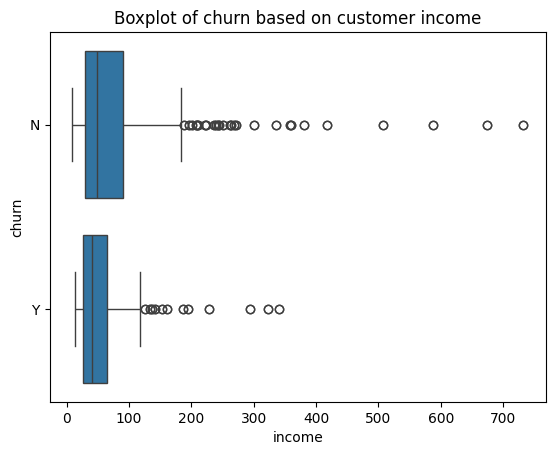

In [16]:
# Examine relationships between numeric and categorical variables: churn by income
snsplot = sns.boxplot(x='income', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer income")



The boxplot compares the distribution of customer income between churned and non churned customers.

Both groups show a similar median income and overlapping interquartile ranges, indicating that income levels are relatively comparable between customers who stayed and those who churned.

However, the distribution is right-skewed in both groups, with several high-income outliers visible, particularly among non-churners. While non-churners appear to have slightly higher income variability and more extreme high-income values, the substantial overlap between the two boxplots suggests that income alone may not be a strong distinguishing factor for churn.

Text(0.5, 1.0, 'Churn Distribution based on customer education')

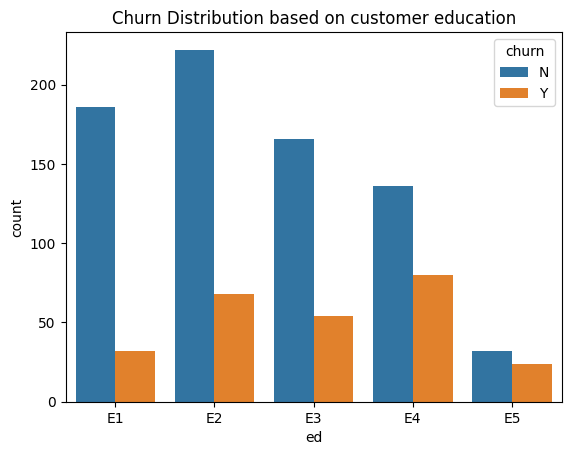

In [17]:
# Countplot to visualize churn distribution based on customer's education
snsplot = sns.countplot(x = 'ed', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer education")

The countplot shows the distribution of churn across customer categories from E1 to E5.

In all categories, non-churned customers (N) outnumber churned customers (Y), indicating generally strong retention across segments. Categories E1, E2, and E3 have the largest customer bases, while E5 has the smallest. Notably, category E4 exhibits a relatively higher proportion of churn, as the gap between retained and churned customers is smaller compared to other groups.

Overall, the plot suggests that churn varies by customer education category, with E4 appearing more prone to churn. This indicates that customer's education category may be a useful factor in identifying high-risk segments for targeted retention strategies.

(0.0, 120.0)

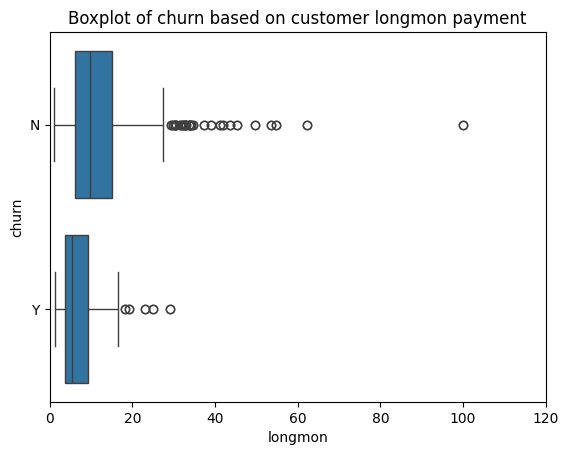

In [18]:
# Examine relationships between numeric and categorical variables: churn by longmon payment
snsplot = sns.boxplot(x='longmon', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer longmon payment")
snsplot.set_xlim([0, 120])

The boxplot compares long-distance monthly charges(longmon) between churned(Y) and non-churned(N) customers.

Non-churned customers exhibit a slightly higher median long-distance payment and a wider distribution compared to churned customers. Churned customers generally have lower median longmon values, with their payments more concentrated in the lower range. Although there is overlap between the two groups, non-churners show greater variability and more high-value outliers.

Overall, the plot suggests that customers with lower long-distance monthly charges may be likely to churn, while those with higher longmon payments tend to remain with the company.

Text(0.5, 1.0, 'Churn Distribution based on Internet Service')

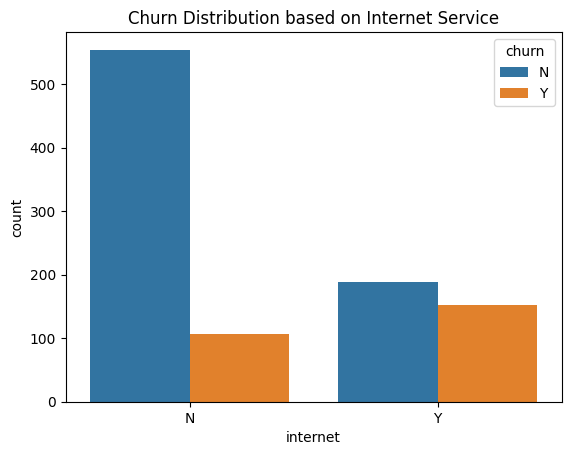

In [19]:
# Countplot to visualize churn distribution based on internet service
snsplot = sns.countplot(x = 'internet', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on Internet Service")

The countplot shows the distribution of churn based on whether customers subscribe to internet service (N= No internet, Y= Yes internet).

Customers without internet service have a much larger number of non-churners compared to churners, indicating relatively strong retention in this group. In contrast, among customers with internet service, the gap between non-churners and churners is small, and the number of churned customers is noticeably higher.

This suggests that customers who subscribe to internet service are more prone to churn compared to those who do not. Therefore, internet service usage appears to be associated with a higher likelihood of churn and may be an important factor in predicting customer retention.

Text(0.5, 1.0, "Churn Distribution based on customer's retirement")

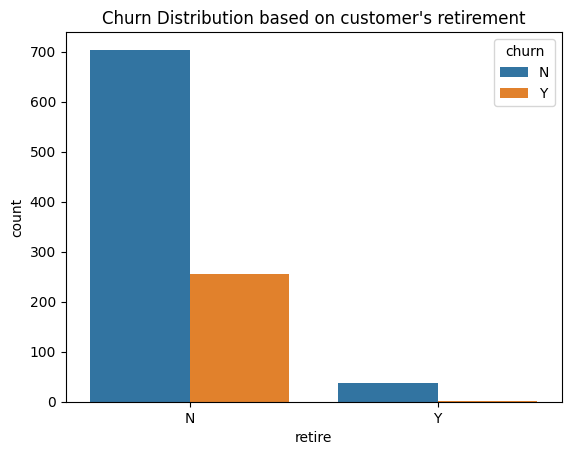

In [20]:
# Countplot to visualize churn distribution based on customer's retirement status
snsplot = sns.countplot(x = 'retire', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer's retirement")

The countplot displays the distribution of churn based on retirement status (N = not retired, Y = retired).

The majority of customers are not retired, and within this group, non-churners significantly outnumber churners. The retired segment is much smaller, and very small number of churn cases are observed in this group. As a result, most churn cases occur among non-retired customers primarily because they represent the largest portion of the dataset, reflecting an overall class imbalance.

Overall, retirement status does not show a clear pattern of higher churn. Given the small size of the retired group and the imbalance in the churn variable, further analysis using balanced data would be necessary to determine whether retirement status meaningfully influences churn.

Text(0.5, 1.0, 'Churn Distribution based on customer category')

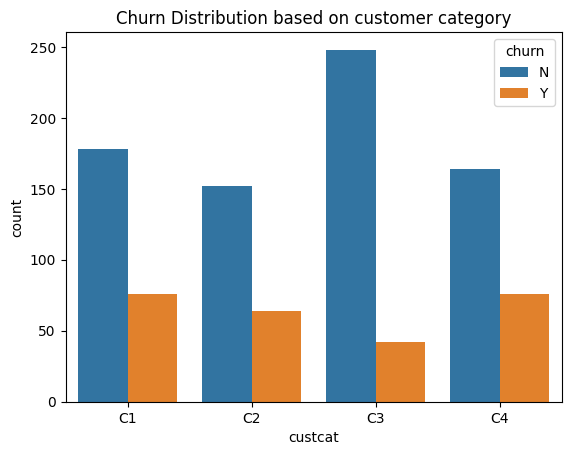

In [21]:
# Countplot to visualize churn distribution based on customer category
snsplot = sns.countplot(x = 'custcat', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer category")

The chart shows the distribution of churn across different customer categories.

In all categories, non-churn customers outnumber churn customers, indicating that most customers remain with the company. However, category C3 has the lowest proportion of churn, suggesting higher customer retention, while categories C1 and C4 exhibit relatively higher churn levels. This indicates that customer category is an important factor influencing churn behavior and may help identify high-risk customer segments.

Text(0.5, 1.0, 'Boxplot of churn based on total charge for calling card service over entire tenure')

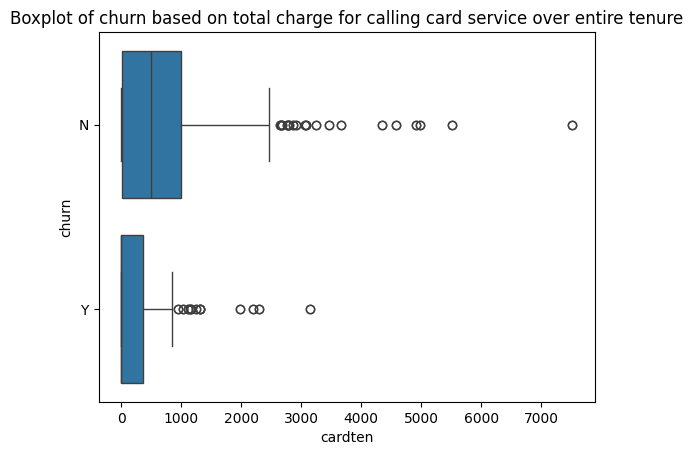

In [22]:
# Examine relationships between numeric and categorical variables: churn by cardten
snsplot = sns.boxplot(x='cardten', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on total charge for calling card service over entire tenure")

The boxplot shows that non-churn customers generally have higher total spending on calling card services over their tenure compared to churn customers. Churn customers are concentrated at lower values of cardten, indicating lower engagement. This suggests that customers with lower usage or shorter tenure are more likely to churn, making cardten an important predictor of churn behavior.

# **3. Partition the Dataset**

In [23]:
# Create dummy variables
customer_churn = pd.get_dummies(customer_churn, columns=['region','marital','ed','retire','gender','tollfree','equip','callcard','wireless','multline','voice','pager','internet','callid','callwait','forward','confer','ebill','custcat'], drop_first=True, dtype= int)
customer_churn

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,...,pager_Y,internet_Y,callid_Y,callwait_Y,forward_Y,confer_Y,ebill_Y,custcat_C2,custcat_C3,custcat_C4
0,13,44,9,64,5,2,3.70,0.00,0.0,7.50,...,0,0,0,0,1,0,0,0,0,0
1,68,52,24,116,29,2,18.15,18.00,0.0,30.25,...,0,0,1,1,0,1,0,0,1,0
2,23,30,9,30,2,4,6.30,0.00,0.0,0.00,...,0,0,1,0,1,1,0,0,1,0
3,45,22,2,19,4,5,10.90,0.00,0.0,8.75,...,0,1,0,1,0,0,1,1,0,0
4,45,59,7,166,31,5,9.75,28.50,0.0,12.00,...,0,0,1,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,43,6,27,4,1,15.00,45.25,0.0,52.75,...,0,0,1,1,1,1,0,0,1,0
996,34,52,2,106,19,2,4.95,19.00,0.0,13.50,...,0,1,1,0,1,1,0,0,1,0
997,15,46,17,63,1,2,3.70,16.50,42.5,0.00,...,1,1,1,0,1,1,1,0,0,1
998,7,34,2,22,5,1,4.65,0.00,25.6,0.00,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Examine the porportion of target variable for data set
target = customer_churn['churn']
print(target.value_counts(normalize=True))

churn
N    0.742
Y    0.258
Name: proportion, dtype: float64


In [25]:
# Partition the data
predictors = customer_churn.drop(['churn'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(700, 43) (300, 43) (700,) (300,)


In [26]:
# Taking steps to balance the train data
# Combine predictors_train and target_train into a single DataFrame
combined_train_df = pd.concat([predictors_train, target_train], axis=1)

# Separate majority and minority classes
majority_df = combined_train_df[combined_train_df['churn'] == 'N']
minority_df = combined_train_df[combined_train_df['churn'] == 'Y']

# Undersample the majority class randomly
undersampled_majority = majority_df.sample(n=len(minority_df), random_state=5)

# Combine the undersampled majority class and the minority class
undersampled_data = pd.concat([undersampled_majority, minority_df])

# Shuffle the combined DataFrame to ensure randomness
balanced_data = undersampled_data.sample(frac=1, random_state=5)

# Split the balanced_data into predictors_train and target_train
predictors_train = balanced_data.drop(columns=['churn'])
target_train = balanced_data['churn']

In [27]:
# Examine the porportion of target variable for train set
print(target_train.value_counts(normalize=True), target_train.shape)

churn
N    0.5
Y    0.5
Name: proportion, dtype: float64 (342,)


In [28]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

churn
N    0.71
Y    0.29
Name: proportion, dtype: float64


# **4. Build Model Prediction**

## I. Decision Tree Model Prediction

### Hypertuning `max_depth` for Decision Tree

In [36]:
best_max_depth = 0
bestDT_f1_y_churn = 0

# Loop through a range of max_depth values
for max_depth_value in range(1, 21):  # Testing max_depth from 1 to 20
    modelDT = DecisionTreeClassifier(criterion="entropy", random_state=1, max_depth=max_depth_value)
    modelDT.fit(predictors_train, target_train)

    prediction_on_test = modelDT.predict(predictors_test)
    report = classification_report(target_test, prediction_on_test, output_dict=True)

    # Get the F1-score for the 'Y' (churn) class
    f1_y_churn = report['Y']['f1-score']

    print(f"\n----- max_depth = {max_depth_value} -----")
    print(classification_report(target_test, prediction_on_test))

    if f1_y_churn > bestDT_f1_y_churn:
        bestDT_f1_y_churn = f1_y_churn
        best_max_depth = max_depth_value

print(f"\nBest max_depth for Decision Tree: {best_max_depth} with F1-score for 'Y' (churn): {bestDT_f1_y_churn:.4f}")


----- max_depth = 1 -----
              precision    recall  f1-score   support

           N       0.81      0.83      0.82       213
           Y       0.55      0.52      0.53        87

    accuracy                           0.74       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.73      0.74      0.73       300


----- max_depth = 2 -----
              precision    recall  f1-score   support

           N       0.81      0.83      0.82       213
           Y       0.55      0.52      0.53        87

    accuracy                           0.74       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.73      0.74      0.73       300


----- max_depth = 3 -----
              precision    recall  f1-score   support

           N       0.78      0.76      0.77       213
           Y       0.45      0.47      0.46        87

    accuracy                           0.68       300
   macro avg       0.61      0.62      0.61    

We focus on recall and F1-score for the churn class because churn prediction is an imbalanced classification problem. From a telecom business perspective, correctly identifying customers at risk of churning is more important than overall accuracy, as missing a churner can result in lost revenue, while false positives primarily incur lower marketing costs. The F1-score is used to balance recall and precision.

### Max_Depth = 10

In [37]:
# Build a decision tree model on training data with max_depth = 10
model_DT1 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 10)
model_DT1.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=1)

[Text(0.48966733870967744, 0.9545454545454546, 'longten <= 111.275\nentropy = 1.0\nsamples = 342\nvalue = [171, 171]\nclass = No'),
 Text(0.1975806451612903, 0.8636363636363636, 'equipten <= 30.875\nentropy = 0.837\nsamples = 146\nvalue = [39, 107]\nclass = Yes'),
 Text(0.3436239919354839, 0.9090909090909092, 'True  '),
 Text(0.12096774193548387, 0.7727272727272727, 'tollmon <= 19.375\nentropy = 0.996\nsamples = 67\nvalue = [31, 36]\nclass = Yes'),
 Text(0.10483870967741936, 0.6818181818181818, 'longten <= 30.875\nentropy = 0.979\nsamples = 53\nvalue = [31, 22]\nclass = No'),
 Text(0.06451612903225806, 0.5909090909090909, 'custcat_C3 <= 0.5\nentropy = 0.828\nsamples = 23\nvalue = [6, 17]\nclass = Yes'),
 Text(0.04838709677419355, 0.5, 'equipten <= 25.85\nentropy = 0.61\nsamples = 20\nvalue = [3, 17]\nclass = Yes'),
 Text(0.03225806451612903, 0.4090909090909091, 'address <= 0.5\nentropy = 0.485\nsamples = 19\nvalue = [2, 17]\nclass = Yes'),
 Text(0.016129032258064516, 0.3181818181818182

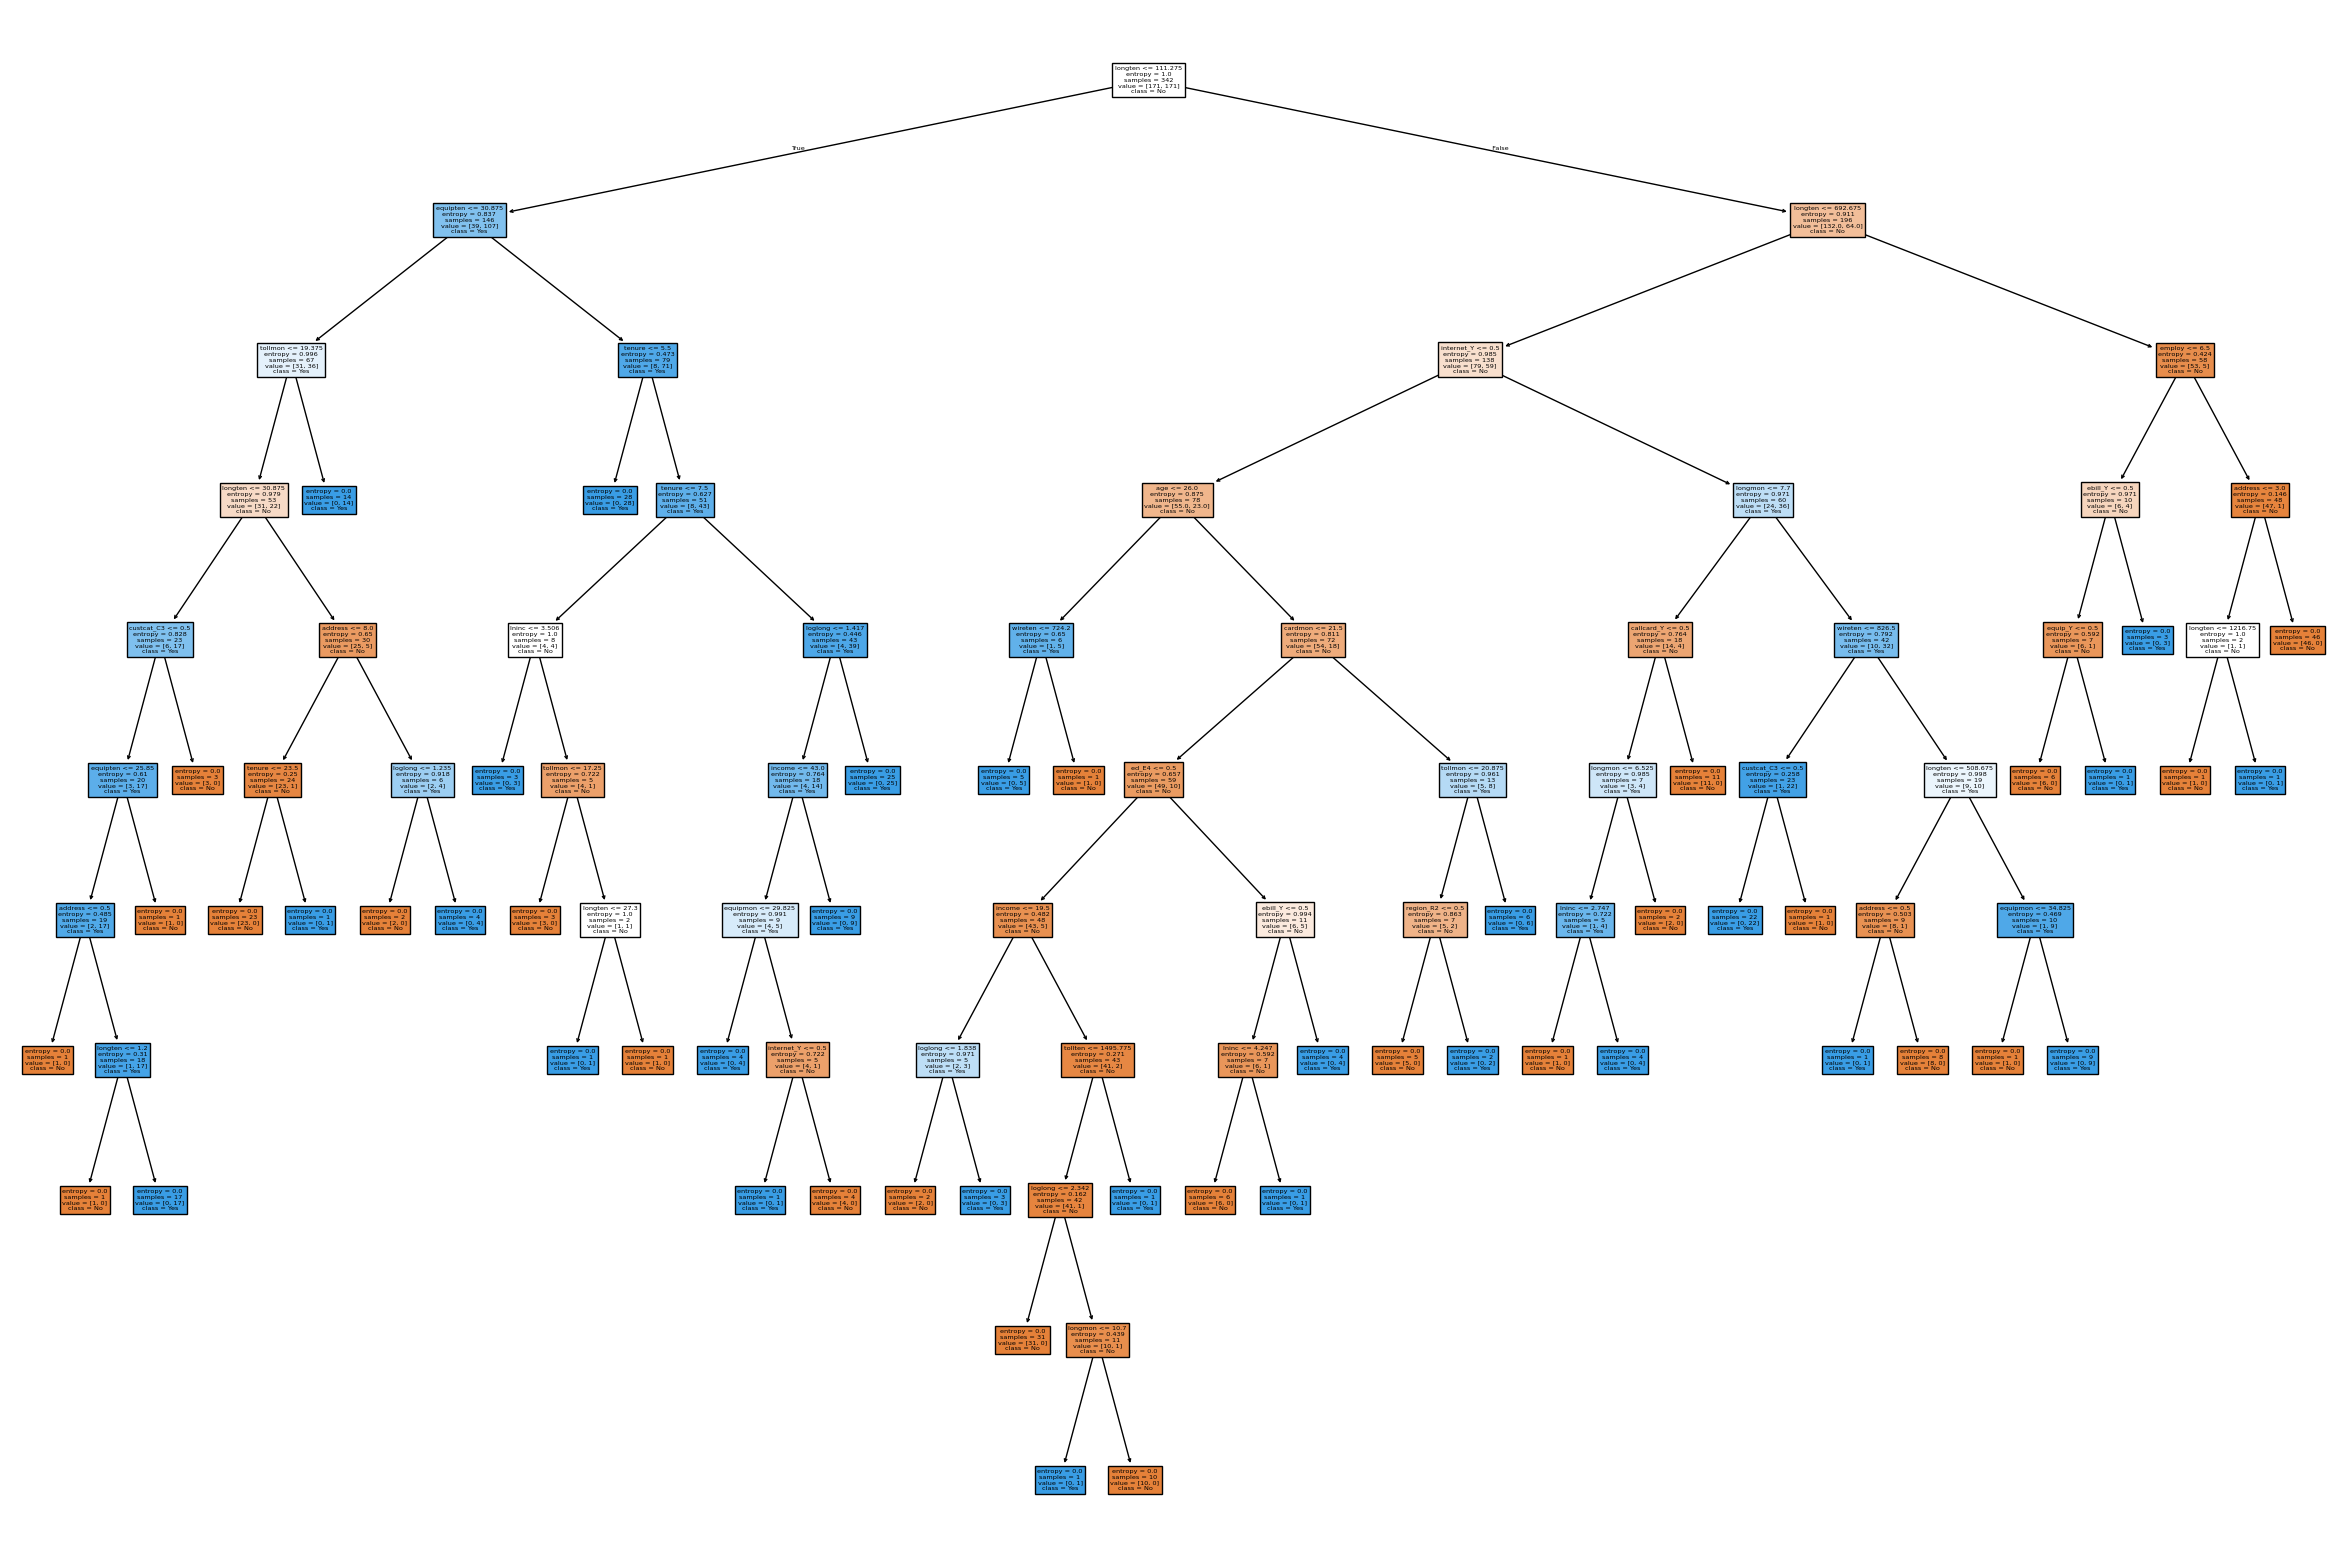

In [38]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model_DT1,
               feature_names=list(predictors_train.columns),
               class_names=['No','Yes'],
               filled=True)

In [39]:
# Text version of decision tree
print(tree.export_text(model_DT1, feature_names=list(customer_churn.columns)[1:]))

|--- tollten <= 111.28
|   |--- cardten <= 30.88
|   |   |--- equipmon <= 19.38
|   |   |   |--- tollten <= 30.88
|   |   |   |   |--- custcat_C3 <= 0.50
|   |   |   |   |   |--- cardten <= 25.85
|   |   |   |   |   |   |--- income <= 0.50
|   |   |   |   |   |   |   |--- class: N
|   |   |   |   |   |   |--- income >  0.50
|   |   |   |   |   |   |   |--- tollten <= 1.20
|   |   |   |   |   |   |   |   |--- class: N
|   |   |   |   |   |   |   |--- tollten >  1.20
|   |   |   |   |   |   |   |   |--- class: Y
|   |   |   |   |   |--- cardten >  25.85
|   |   |   |   |   |   |--- class: N
|   |   |   |   |--- custcat_C3 >  0.50
|   |   |   |   |   |--- class: N
|   |   |   |--- tollten >  30.88
|   |   |   |   |--- income <= 8.00
|   |   |   |   |   |--- age <= 23.50
|   |   |   |   |   |   |--- class: N
|   |   |   |   |   |--- age >  23.50
|   |   |   |   |   |   |--- class: Y
|   |   |   |   |--- income >  8.00
|   |   |   |   |   |--- lninc <= 1.24
|   |   |   |   |   |   |--- clas

The decision tree shows that the most important variable influencing churn is tollten, as it appears at the root node and determines the primary split in the data. This indicates that customer usage or tenure in toll services is the strongest predictor of churn.

Other key variables include cardten and several monthly usage variables such as tollmon, equipmon, cardmon, and wiremon, which appear frequently and influence multiple branches of the tree. These variables suggest that customer engagement and service usage play a major role in predicting churn.

Additionally, income is an important factor, indicating that financial status affects customer behavior. Demographic variables such as age, employment, education, and customer category also contribute to the prediction.

Finally, service-related variables like internet usage and e-billing, as well as stability indicators such as residence length, further refine the prediction.

Overall, the model suggests that service usage and tenure are the primary drivers of churn, followed by income and customer characteristics.

In [40]:
# Make predictions on testing data
prediction_on_test = model_DT1.predict(predictors_test)

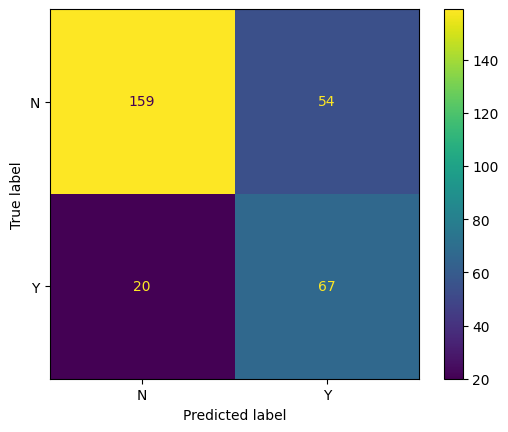

In [41]:
# Examine the evaluation results on testing data: confusion_matrix
cm_DT1 = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm_DT1, display_labels=model_DT1.classes_).plot()

In [42]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           N       0.89      0.75      0.81       213
           Y       0.55      0.77      0.64        87

    accuracy                           0.75       300
   macro avg       0.72      0.76      0.73       300
weighted avg       0.79      0.75      0.76       300



The decision tree model achieves an overall accuracy of 0.75, indicating a moderate level of performance. The model performs well in identifying non-churn customers, with high precision (0.89) and good recall (0.75), resulting in a strong F1-score of 0.81.

However, for churn customers, the model shows lower precision (0.55) but relatively higher recall (0.77). This indicates that while the model is able to identify a large proportion of actual churn customers, it also incorrectly classifies many non-churn customers as churn.

Overall, the model is more effective at predicting non-churn customers and tends to over-predict churn, leading to lower precision for the churn class.

## II. K Nearest Neighbor Model Prediction

### Scale numerical data for KNN

In [44]:
# Identify numerical columns that need scaling
numerical_cols = ['tenure', 'age', 'address', 'income', 'employ', 'reside',
                  'longmon', 'tollmon', 'equipmon', 'cardmon', 'wiremon',
                  'longten', 'tollten', 'equipten', 'cardten', 'wireten',
                  'loglong', 'lninc']

# Initialize the StandardScaler
scaler = preprocessing.StandardScaler()

# Create copies to avoid modifying original predictors_train/test in place before scaling
predictors_train = predictors_train.copy()
predictors_test = predictors_test.copy()

# Apply scaling to the numerical columns in training and testing sets
predictors_train[numerical_cols] = scaler.fit_transform(predictors_train[numerical_cols])
predictors_test[numerical_cols] = scaler.transform(predictors_test[numerical_cols])

display(predictors_train.head())

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,...,pager_Y,internet_Y,callid_Y,callwait_Y,forward_Y,confer_Y,ebill_Y,custcat_C2,custcat_C3,custcat_C4
187,-1.040282,0.230469,-0.630770,-0.023239,-0.456255,-0.894146,-0.657479,-0.811838,-0.85155,-0.852907,...,0,0,0,0,0,0,0,0,0,0
719,0.891493,-0.407752,0.088650,-0.254842,0.659760,0.583138,0.449027,0.692611,-0.85155,0.360404,...,0,0,1,1,0,0,0,0,1,0
657,-0.569117,2.224910,-0.939092,3.219207,2.587422,0.583138,-0.776033,0.485101,-0.85155,1.234701,...,1,0,1,1,1,1,0,0,0,1
248,-0.522001,-0.726863,0.191425,-0.571773,-0.557711,1.321780,0.356818,-0.811838,-0.85155,-0.852907,...,0,0,0,0,0,0,1,1,0,0
914,-0.286418,-1.205529,-0.836318,-0.523014,-0.862078,2.060422,-0.696997,-0.811838,-0.85155,-0.852907,...,0,0,0,0,0,0,0,1,0,0


### K-Nearest Neighbor with scaled data

In [47]:
best_k = 0
best_KNN_f1_y_churn = 0

# Loop through a range of n_neighbors values
for k_value in range(1, 21, 2):  # Testing odd k values from 1 to 19
    modelKNN = KNeighborsClassifier(n_neighbors=k_value)
    modelKNN.fit(predictors_train, target_train)

    prediction_on_test_knn = modelKNN.predict(predictors_test)
    report_knn = classification_report(target_test, prediction_on_test_knn, output_dict=True)

    # Get the F1-score for the 'Y' (churn) class
    f1_y_churn_knn = report_knn['Y']['f1-score']

    print(f"\n----- k = {k_value} (Scaled Data) -----")
    print(classification_report(target_test, prediction_on_test_knn))

    if f1_y_churn_knn > best_KNN_f1_y_churn:
        best_KNN_f1_y_churn = f1_y_churn_knn
        best_k = k_value

print(f"\nBest k for K-Nearest Neighbor with Scaled Data: {best_k}, with F1-score for 'Y' (churn) of: {best_KNN_f1_y_churn:.4f}")


----- k = 1 (Scaled Data) -----
              precision    recall  f1-score   support

           N       0.93      0.77      0.84       213
           Y       0.60      0.86      0.71        87

    accuracy                           0.80       300
   macro avg       0.77      0.82      0.78       300
weighted avg       0.84      0.80      0.80       300


----- k = 3 (Scaled Data) -----
              precision    recall  f1-score   support

           N       0.80      0.68      0.73       213
           Y       0.42      0.57      0.49        87

    accuracy                           0.65       300
   macro avg       0.61      0.63      0.61       300
weighted avg       0.69      0.65      0.66       300


----- k = 5 (Scaled Data) -----
              precision    recall  f1-score   support

           N       0.83      0.68      0.75       213
           Y       0.46      0.67      0.54        87

    accuracy                           0.68       300
   macro avg       0.65      

The KNN model with k=1 achieves the best performance on the scaled test data, with the highest F1-score for churn customers (0.71). The improvement after scaling indicates that KNN, being distance-based, benefits significantly from having features on a comparable scale.

Although k=1 is typically associated with overfitting, it performs well in this case likely due to strong local patterns in the data and the relatively small sample size. Additionally, because the dataset is imbalanced, k=1 is more effective at capturing minority class (churn) observations, resulting in higher recall, while larger values of k tend to favor the majority class and reduce performance.

However, strong performance on a single test set does not guarantee good generalization. Since k=1 is highly sensitive to noise and has high variance, its performance may vary across different samples. Therefore, cross-validation is recommended to confirm whether it consistently outperforms other values of k. In practice, slightly larger values of k are often preferred for more stable and robust performance.

## III. MLP Model Prediction

In [48]:
#Build MLP model contains two hidden layers: 64 hidden nodes for the first layer, 16 hidden nodes for the second layer, and 8 hidden nodes for the third layer. Set random_state=1.

model_MLP1 = MLPClassifier(hidden_layer_sizes=(64,16,8), activation='relu', random_state=1)
model_MLP1.fit(predictors_train, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 16, 8), random_state=1)

In [49]:
# Make predictions on testing data
prediction_on_test = model_MLP1.predict(predictors_test)

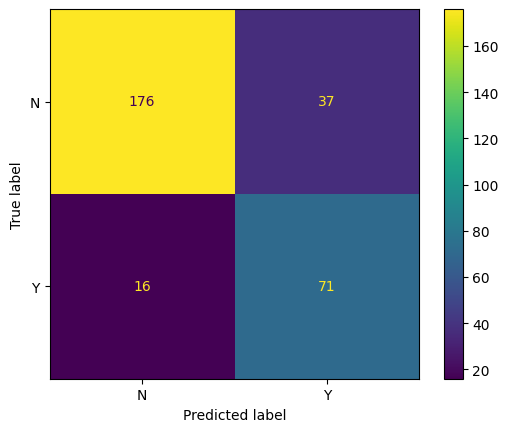

In [50]:
# Examine the evaluation results on testing data: confusion_matrix

cm_MLP1 = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm_MLP1, display_labels=model_MLP1.classes_).plot()

In [51]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           N       0.92      0.83      0.87       213
           Y       0.66      0.82      0.73        87

    accuracy                           0.82       300
   macro avg       0.79      0.82      0.80       300
weighted avg       0.84      0.82      0.83       300



The MLP model demonstrates strong recall for churn prediction, reflecting its ability to capture complex nonlinear relationships in the data. However, as a black-box model, it is less interpretable than tree-based models and more sensitive to data size and parameter tuning. Although it performs competitively, its limited interpretability makes it less suitable for business decision-making compared to models such as Random Forest, where model behavior can be more easily understood and communicated.

Similar to the previous models, performs very well in identifying non-churn customers, which is influenced by the class imbalance in the dataset. For churn prediction, the model achieves a high recall of 0.82, indicating that it successfully identifies most churn customers.

However, the precision for churn is relatively lower at 0.66, meaning that some non-churn customers are incorrectly classified as churn (false positives). As a result, while the model is effective at detecting churn customers, it tends to over-predict churn.

## IV. Random Forest Model Prediction

### Hypertuning n_estimators and max_depth values for Random Forest Model

In [52]:
best_rf_n_estimators = 0
best_rf_max_depth = 0
best_rf_f1_y = 0

# Define ranges for n_estimators and max_depth
n_estimators_values = [10, 30, 50, 100]
max_depth_values = [5, 11, 15, 20]

for n_est in n_estimators_values:
    for m_depth in max_depth_values:
        # Build a Random Forest model
        model_RF = RandomForestClassifier(n_estimators=n_est, max_depth=m_depth, random_state=1)
        model_RF.fit(predictors_train, target_train)

        # Make predictions on testing data
        prediction_on_test_RF = model_RF.predict(predictors_test)
        report_RF = classification_report(target_test, prediction_on_test_RF, output_dict=True)

        # Get the F1-score for the 'Y' class (churn)
        f1_y_RF = report_RF['Y']['f1-score']

        print(f"\n----- n_estimators = {n_est}, max_depth = {m_depth} -----")
        print(classification_report(target_test, prediction_on_test_RF))

        if f1_y_RF > best_rf_f1_y:
            best_rf_f1_y = f1_y_RF
            best_rf_n_estimators = n_est
            best_rf_max_depth = m_depth

print(f"\nBest Random Forest Hyperparameters: n_estimators={best_rf_n_estimators}, max_depth={best_rf_max_depth}")
print(f"With F1-score for 'Y' (churn) of: {best_rf_f1_y:.4f}")


----- n_estimators = 10, max_depth = 5 -----
              precision    recall  f1-score   support

           N       0.89      0.83      0.86       213
           Y       0.64      0.75      0.69        87

    accuracy                           0.81       300
   macro avg       0.77      0.79      0.78       300
weighted avg       0.82      0.81      0.81       300


----- n_estimators = 10, max_depth = 11 -----
              precision    recall  f1-score   support

           N       0.91      0.86      0.88       213
           Y       0.70      0.78      0.74        87

    accuracy                           0.84       300
   macro avg       0.80      0.82      0.81       300
weighted avg       0.85      0.84      0.84       300


----- n_estimators = 10, max_depth = 15 -----
              precision    recall  f1-score   support

           N       0.87      0.87      0.87       213
           Y       0.68      0.68      0.68        87

    accuracy                           0.8

The Random Forest model demonstrates strong performance in predicting customer churn, achieving an F1-score of 0.77 for the churn class, with a recall of 0.82 and precision of 0.72. While the model performs exceptionally well in identifying non-churn customers, it maintains a good balance between recall and precision for churn prediction despite the class imbalance.

The relatively higher recall indicates that the model successfully identifies most churn customers, though some false positives remain. From a business perspective, this trade-off is acceptable, as missing churn customers can lead to significant revenue loss, whereas false positives mainly incur additional marketing or retention costs.

# **Final Model Selection**

Multiple models were evaluated for customer churn prediction, including Decision Tree, K-Nearest Neighbors (KNN), Multi-Layer Perceptron (MLP), and Random Forest. Model performance was assessed with a focus on recall and F1-score for the churn class, as churn prediction is an imbalanced classification problem and identifying at-risk customers is critical for business decision-making.

Among the models, KNN (k = 1) achieved the highest recall for churn prediction, indicating strong ability to identify customers likely to leave. However, this model may suffer from overfitting, as it is highly sensitive to noise and relies on a single nearest neighbor, which can limit its generalization to new data. The Decision Tree model provides clear interpretability and insight into key drivers of churn, such as tenure and service usage, but its performance is less stable and may be prone to overfitting compared to ensemble methods.

The MLP model also demonstrated strong recall, reflecting its ability to capture complex nonlinear relationships in the data. However, as a black-box model, it lacks interpretability and is more difficult to apply in a business context where understanding key drivers is important.

The Random Forest model was selected as the final model due to its strong balance between recall and precision, achieving a high F1-score for the churn class. Compared to other models, Random Forest provides more stable and reliable performance while still effectively identifying churn customers. Although the model tends to over-predict churn, resulting in some false positives, this trade-off is acceptable from a business perspective. The cost of incorrectly targeting a non-churn customer is typically lower than the revenue loss associated with failing to identify an actual churner.



# **Limitations**

Despite Random Forest predictive model's strong performance, the model has several limitations. The class imbalance in the dataset contributes to lower precision for churn prediction, resulting in a higher number of false positives. In addition, hyperparameter tuning was performed using the test set, which may introduce bias and lead to overly optimistic performance estimates.

The KNN model may suffer from overfitting due to its reliance on a single nearest neighbor, while the Decision Tree model is sensitive to small changes in the data and may not generalize well. The MLP model may also benefit from further hyperparameter tuning, as neural networks are highly sensitive to architecture and training parameters.

Future improvements could include applying more robust validation techniques, such as cross-validation, and incorporating additional behavioral or customer interaction data. Examples include customer service interactions (e.g., complaints or dissatisfaction), contract or plan changes (e.g., frequent switching or service downgrades), and payment behavior (e.g., late or missed payments). These variables may capture early warning signs of churn and further improve predictive performance.


# **Conclusion from a business standpoint**

In conclusion, the Random Forest model provides a practical and effective solution for churn prediction, supporting data-driven decision-making and enabling more targeted and cost-efficient customer retention strategies, particularly for newly acquired and early-stage customers who are at higher risk of churn.

By leveraging the model’s predictions, the company can shift from broad, untargeted retention strategies to focused interventions aimed at high-risk customers. This improves resource allocation and enhances the effectiveness of retention efforts.

Key drivers of churn identified in the analysis include low tenure and low service engagement, indicating that newer and less active customers are more likely to leave. Therefore, retention strategies should prioritize early-stage customers through targeted incentives, personalized engagement, and programs designed to increase customer usage and long-term retention.

**Recommended actions:**
- Use the model to trigger early-stage interventions for customers with low tenure and declining service engagement: improved onboarding, personalised outreach, and targeted incentives designed to increase product usage.
- Prioritise customers with repeated complaints or dissatisfaction signals and monitor plan downgrades or frequent changes as early warning indicators.